In [31]:
import cv2
import numpy as np
import random
import os
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt

In [32]:
from pathlib import Path

# Project root: walk up from cwd until pyproject.toml (so Cursor/Jupyter cwd doesn't break paths)
_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
if not (_repo / "pyproject.toml").exists():
    raise FileNotFoundError("Run from clash_royacado repo or open terminal there — could not find project root.")

# Folder of frames (not a single .png). os.listdir() needs a directory.
sprite_path = str(_repo / "cr-assets-png/assets/sc/chr_black_knight_out")

In [33]:
paths = os.listdir(sprite_path)
paths.sort()

In [34]:
ims = []
for i in paths:
    if("ipynb" in i):
        continue
    f = os.path.join(sprite_path,i)
    with Image.open(f) as img:
        # Convert the image object to a NumPy array
        arr = np.array(img)
        ims.append(arr)

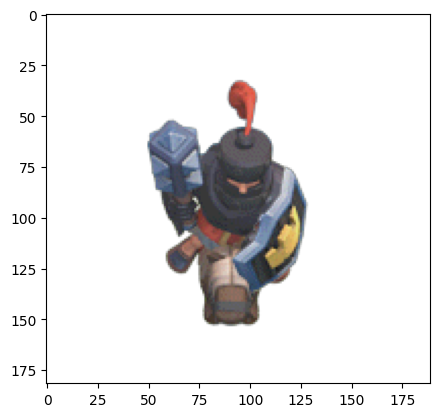

In [35]:
plt.imshow(ims[0])

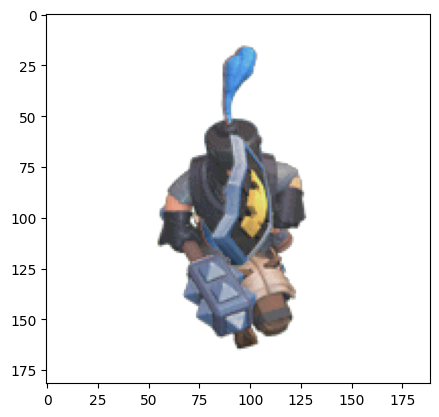

In [36]:
plt.imshow(ims[34])

In [37]:
import cv2
import os
import glob

def create_video_from_images(image_folder, output_video_file, fps=30):
    """
    Converts images in a folder to a video file using OpenCV.
    
    Args:
        image_folder (str): Path to folder containing images.
        output_video_file (str): Output filename (e.g., 'output.mp4').
        fps (int): Frames per second.
    """
    
    # 1. Load and Sort Images
    # We grab .png, .jpg, and .jpeg. Adjust extension if needed.
    images = glob.glob(os.path.join(image_folder, "*.png")) + \
             glob.glob(os.path.join(image_folder, "*.jpg")) + \
             glob.glob(os.path.join(image_folder, "*.jpeg"))
    
    # CRITICAL: Sort images to ensure they appear in the correct order
    # (e.g., img1.png, img2.png...)
    images.sort()

    if not images:
        print(f"Error: No images found in {image_folder}")
        return

    # 2. Read the first frame to determine video resolution
    # OpenCV VideoWriter requires ALL frames to be the exact same size.
    frame = cv2.imread(images[0])
    height, width, layers = frame.shape
    size = (width, height)

    print(f"Detected Resolution: {width}x{height}")

    # 3. Define the Codec
    # Based on your config (FFMPEG: YES), 'mp4v' is the safest option for .mp4
    # Alternative: 'XVID' for .avi files if mp4v fails.
    fourcc = cv2.VideoWriter_fourcc(*'VP80') 
    
    # 4. Initialize VideoWriter
    out = cv2.VideoWriter(output_video_file, fourcc, fps, size)

    print(f"Processing {len(images)} frames...")

    for i, filename in enumerate(images):
        img = cv2.imread(filename)

        # Bottom-right corner
        h, w = img.shape[:2]
        text = str(i)
        
        font = cv2.FONT_HERSHEY_SIMPLEX
        scale = 1
        thickness = 2
        
        # Get text size
        (text_w, text_h), _ = cv2.getTextSize(text, font, scale, thickness)
        
        # Position with small margin
        x = w - text_w - 10
        y = h - 10
        
        cv2.putText(
            img,
            text,
            (x, y),
            font,
            scale,
            (255, 255, 255),  # white
            thickness,
            cv2.LINE_AA
        )
                
        # Safety Check: Resize image if it doesn't match the first frame's size
        # (Otherwise the video generation will silently fail or corrupt)
        if (img.shape[1], img.shape[0]) != size:
            img = cv2.resize(img, size)
            
        out.write(img)

    # 5. Release resources
    out.release()
    print(f"Success! Video saved to: {output_video_file}")


In [38]:

def create_video_from_image_list(images, output_video_file, fps=30):
    """
    Converts images in a folder to a video file using OpenCV.
    
    Args:
        image_folder (str): Path to folder containing images.
        output_video_file (str): Output filename (e.g., 'output.mp4').
        fps (int): Frames per second.
    """
    
    # 1. Load and Sort Images
    # We grab .png, .jpg, and .jpeg. Adjust extension if needed.
    
    # CRITICAL: Sort images to ensure they appear in the correct order
    # (e.g., img1.png, img2.png...)
    images.sort()

    if not images:
        print(f"Error: No images found in {image_folder}")
        return

    # 2. Read the first frame to determine video resolution
    # OpenCV VideoWriter requires ALL frames to be the exact same size.
    frame = cv2.imread(images[0])
    height, width, layers = frame.shape
    size = (width, height)

    print(f"Detected Resolution: {width}x{height}")

    # 3. Define the Codec
    # Based on your config (FFMPEG: YES), 'mp4v' is the safest option for .mp4
    # Alternative: 'XVID' for .avi files if mp4v fails.
    fourcc = cv2.VideoWriter_fourcc(*'VP80') 
    
    # 4. Initialize VideoWriter
    out = cv2.VideoWriter(output_video_file, fourcc, fps, size)

    print(f"Processing {len(images)} frames...")

    for i, filename in enumerate(images):
        img = cv2.imread(filename)

        # Bottom-right corner
        h, w = img.shape[:2]
        text = str(i)
        
        font = cv2.FONT_HERSHEY_SIMPLEX
        scale = 1
        thickness = 2
        
        # Get text size
        (text_w, text_h), _ = cv2.getTextSize(text, font, scale, thickness)
        
        # Position with small margin
        x = w - text_w - 10
        y = h - 10
        
    
                
        # Safety Check: Resize image if it doesn't match the first frame's size
        # (Otherwise the video generation will silently fail or corrupt)
        if (img.shape[1], img.shape[0]) != size:
            img = cv2.resize(img, size)
            
        out.write(img)

    # 5. Release resources
    out.release()
    print(f"Success! Video saved to: {output_video_file}")


In [39]:
create_video_from_images(sprite_path, "sprite_wiz.webm", fps=16)

Detected Resolution: 189x182
Processing 1016 frames...


OpenCV: FFMPEG: tag 0x30385056/'VP80' is not supported with codec id 139 and format 'webm / WebM'


Success! Video saved to: sprite_wiz.webm


In [40]:
m = 8
start = 0
end = 72
d = {}
for i in range(m):
    c = start + i
    d[i] = []
    while(c<=end and len(d[i])<9):
        full_path = os.path.join(sprite_path, paths[c])
        d[i].append(full_path)
        c += m
        

In [41]:
a = ims[start]
b= ims[start+m]
c= ims[start+3*m]

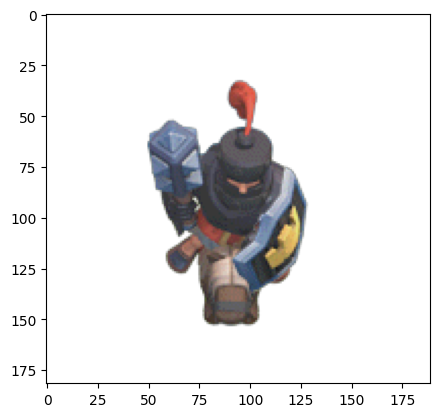

In [42]:
plt.imshow(a)

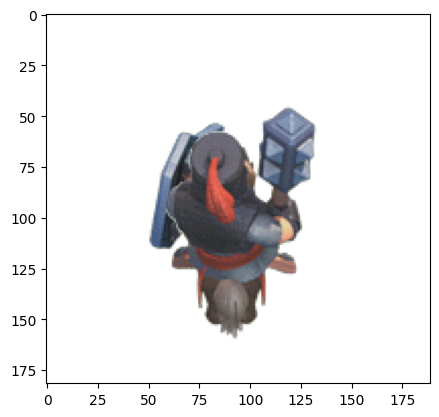

In [43]:
plt.imshow(b)

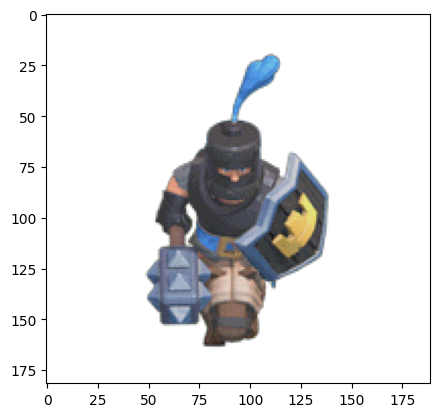

In [44]:
plt.imshow(c)

In [45]:
# frame i rotation
i = 3
i_frames = ims[i::m]
i_paths = paths[i::m]
# angle j motion
j = 15
j_frames = ims[j - j%m: j - j%m + m]
j_paths =  paths[j - j%m: j - j%m + m]

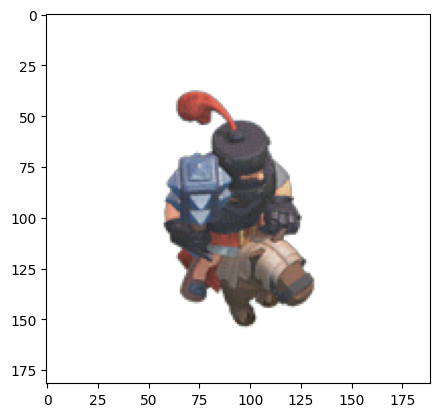

In [46]:
plt.imshow(j_frames[3])

In [47]:
import shutil
import os

# 1. Define your list of image paths and the destination folder
destination_dir = 'wizard_run'
os.makedirs(destination_dir, exist_ok = True)

# 3. Iterate and copy
for path in j_paths:
    whole_path = os.path.join(sprite_path, path)
    if os.path.isfile(whole_path): # Check if file exists to avoid errors
        shutil.copy(whole_path, destination_dir)
        print(whole_path)
    else:
        print("not path: ", whole_path)

/Users/langdonhuynh/cody-cr/clash_royacado/cr-assets-png/assets/sc/chr_black_knight_out/chr_black_knight_sprite_0008.png
/Users/langdonhuynh/cody-cr/clash_royacado/cr-assets-png/assets/sc/chr_black_knight_out/chr_black_knight_sprite_0009.png
/Users/langdonhuynh/cody-cr/clash_royacado/cr-assets-png/assets/sc/chr_black_knight_out/chr_black_knight_sprite_0010.png
/Users/langdonhuynh/cody-cr/clash_royacado/cr-assets-png/assets/sc/chr_black_knight_out/chr_black_knight_sprite_0011.png
/Users/langdonhuynh/cody-cr/clash_royacado/cr-assets-png/assets/sc/chr_black_knight_out/chr_black_knight_sprite_0012.png
/Users/langdonhuynh/cody-cr/clash_royacado/cr-assets-png/assets/sc/chr_black_knight_out/chr_black_knight_sprite_0013.png
/Users/langdonhuynh/cody-cr/clash_royacado/cr-assets-png/assets/sc/chr_black_knight_out/chr_black_knight_sprite_0014.png
/Users/langdonhuynh/cody-cr/clash_royacado/cr-assets-png/assets/sc/chr_black_knight_out/chr_black_knight_sprite_0015.png


In [48]:
whole_path

'/Users/langdonhuynh/cody-cr/clash_royacado/cr-assets-png/assets/sc/chr_black_knight_out/chr_black_knight_sprite_0015.png'

In [49]:
h,w, c = j_frames[0].shape

In [50]:
grid = np.zeros((h*3, w *3, c)).astype("uint")

In [51]:
for ix, i in enumerate(j_frames):
    h_ix = ix//3
    w_ix = ix%3
    grid[h_ix*h:(h_ix+1)*h,w_ix*w:(w_ix+1)*w] = i

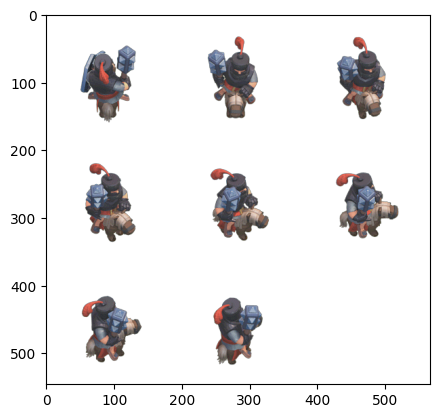

In [52]:
plt.imshow(grid)

In [53]:

img = Image.fromarray(grid.astype(np.uint8))
img.save(os.path.join(destination_dir,"grid.png"))
